In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, log, ceil

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, QFT
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import time


def build_mod_mult_unitary(k, N, n_bits):
    """Build the unitary matrix for 'multiply by k mod N'.

    Each input state |x> maps to |x*k mod N> for valid inputs.
    This is a permutation matrix — always unitary.
    """
    dim = 2**n_bits
    U = np.zeros((dim, dim))
    for x in range(dim):
        if x == 0:
            U[0][0] = 1
        elif x < N and gcd(x, N) == 1:
            y = (x * k) % N
            U[y][x] = 1
        else:
            U[x][x] = 1
    return U


def build_shor_circuit(N, a, num_control, num_target):
    """Build the complete Shor's circuit with named registers.

    Returns the circuit and the number of controlled multiplications applied.
    """
    control = QuantumRegister(num_control, name='Counting')
    target  = QuantumRegister(num_target,  name='Target')
    output  = ClassicalRegister(num_control, name='output')
    circuit = QuantumCircuit(control, target, output)

    # Step 1: Initialise target register to |1>
    circuit.x(num_control)

    # Step 2: Hadamard on all counting qubits
    for k in range(num_control):
        circuit.h(k)

    circuit.barrier()

    # Step 3: Controlled modular exponentiation
    n_mod_mults = 0
    for k in range(num_control):
        power = pow(a, 2**k, N)
        if power == 1:
            continue
        U     = build_mod_mult_unitary(power, N, num_target)
        gate  = UnitaryGate(U)
        gate.name = f'M_{power}'
        c_gate = gate.control()
        circuit.compose(c_gate,
                        qubits=[k] + list(range(num_control, num_control + num_target)),
                        inplace=True)
        n_mod_mults += 1

    circuit.barrier()

    # Step 4: Inverse QFT on counting register
    circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)

    circuit.barrier()

    # Step 5: Measure counting register
    circuit.measure(control, output)

    return circuit, n_mod_mults

In [14]:
# ── Connect to IBM Quantum ────────────────────────────────────────────────
#
# First time only — paste your API token from https://quantum.ibm.com
# After running this once the token is saved and you never need it again.
#
QiskitRuntimeService.save_account(
    channel='ibm_quantum_platform',
    token='zbAsMNyeoo4YfwQj5PZAtT7HS4Srv0jKZLb8VAdXExsj',
    instance='crn:v1:bluemix:public:quantum-computing:us-east:a/7b51e867d80d4d91b91245206f368ad4:681060a7-5b8a-4ade-b759-c1690e9159bc::',      # ← paste the CRN you copied
    overwrite=True
)

service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Automatically pick the least busy real device with >= 12 qubits
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=12)

print(f'Connected to:      {backend.name}')
print(f'Qubits available:  {backend.num_qubits}')
print(f'Basis gates:       {backend.basis_gates}')

Connected to:      ibm_fez
Qubits available:  156
Basis gates:       ['cz', 'id', 'rz', 'sx', 'x']


In [15]:
# ── Build circuit for N=15, a=2 ───────────────────────────────────────────
N           = 15
a           = 2
num_target  = ceil(log(N, 2))   # 4 qubits
num_control = 2 * num_target    # 8 qubits

print(f"Building Shor's circuit: N={N}, a={a}")
print(f'Counting qubits:  {num_control}')
print(f'Target qubits:    {num_target}')
print(f'Total qubits:     {num_control + num_target}')

print('\nCounting qubit → Controlled multiplication:')
for k in range(num_control):
    power = pow(a, 2**k, N)
    skip  = ' (skip: identity)' if power == 1 else ''
    print(f'  Qubit {k}: a^(2^{k}) mod {N} = {a}^{2**k} mod {N} = {power}{skip}')

circuit, n_mults = build_shor_circuit(N, a, num_control, num_target)
print(f'\nControlled multiplications applied: {n_mults}')

Building Shor's circuit: N=15, a=2
Counting qubits:  8
Target qubits:    4
Total qubits:     12

Counting qubit → Controlled multiplication:
  Qubit 0: a^(2^0) mod 15 = 2^1 mod 15 = 2
  Qubit 1: a^(2^1) mod 15 = 2^2 mod 15 = 4
  Qubit 2: a^(2^2) mod 15 = 2^4 mod 15 = 1 (skip: identity)
  Qubit 3: a^(2^3) mod 15 = 2^8 mod 15 = 1 (skip: identity)
  Qubit 4: a^(2^4) mod 15 = 2^16 mod 15 = 1 (skip: identity)
  Qubit 5: a^(2^5) mod 15 = 2^32 mod 15 = 1 (skip: identity)
  Qubit 6: a^(2^6) mod 15 = 2^64 mod 15 = 1 (skip: identity)
  Qubit 7: a^(2^7) mod 15 = 2^128 mod 15 = 1 (skip: identity)

Controlled multiplications applied: 2


C:\Users\User\AppData\Local\Temp\ipykernel_7680\4019572837.py:70: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


In [16]:
# ── Transpile for the real device ─────────────────────────────────────────
#
# generate_preset_pass_manager replaces transpile() for real hardware.
# It decomposes UnitaryGate into native gates and handles qubit routing
# (inserting SWAP gates where direct qubit connections don't exist).

pm               = generate_preset_pass_manager(backend=backend, optimization_level=1)
compiled_circuit = pm.run(circuit)

total_gates = sum(compiled_circuit.count_ops().values())
print(f'Transpiled for:  {backend.name}')
print(f'Total gates:     {total_gates}')
print(f'Circuit depth:   {compiled_circuit.depth()}')
print(f'Gate breakdown:  {dict(compiled_circuit.count_ops())}')

Transpiled for:  ibm_fez
Total gates:     6586
Circuit depth:   3907
Gate breakdown:  {'sx': 2882, 'rz': 2459, 'cz': 1233, 'measure': 8, 'barrier': 3, 'x': 1}


In [17]:
# ── Submit job to IBM hardware ────────────────────────────────────────────
#
# SamplerV2 replaces backend.run() — it is IBM's modern execution interface.
# shots=1024 (vs 4096 in simulation) to conserve the free tier quota
# of 10 minutes/month execution time.
#
# Save the printed Job ID — if your session disconnects before the job
# finishes you can retrieve results later with:
#   job = service.job('YOUR_JOB_ID_HERE')

shots   = 1024
sampler = SamplerV2(backend)
job     = sampler.run([compiled_circuit], shots=shots)

print(f'Job submitted!')
print(f'Job ID:   {job.job_id()}')
print(f'Status:   {job.status()}')
print(f'Shots:    {shots}')
print(f'\nWaiting for job to complete (may take several minutes)...')

Job submitted!
Job ID:   d6rg1a4u243c73a1cso0
Status:   QUEUED
Shots:    1024

Waiting for job to complete (may take several minutes)...


In [18]:
# ── Retrieve results ──────────────────────────────────────────────────────
#
# If session disconnected, restore the job with:
#   job = service.job('YOUR_JOB_ID_HERE')
#
# Key difference from simulator:
#   Simulator:  result.get_counts()
#   Hardware:   result[0].data.output.get_counts()
#     result[0]       → first circuit's result
#     .data           → measurement data
#     .output         → our ClassicalRegister named 'output'
#     .get_counts()   → bitstring → count dictionary

result   = job.result()
counts   = result[0].data.output.get_counts()

print(f'Job complete!')
print(f'Unique outcomes: {len(counts)}')
print(f'Total shots:     {sum(counts.values())}')
print(f'\nTop 10 results:')
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    print(f'  {bs}  (decimal {int(bs, 2):3d})  →  {cnt} shots  ({100*cnt/shots:.1f}%)')

Job complete!
Unique outcomes: 252
Total shots:     1024

Top 10 results:
  00010000  (decimal  16)  →  11 shots  (1.1%)
  00011100  (decimal  28)  →  11 shots  (1.1%)
  01010000  (decimal  80)  →  10 shots  (1.0%)
  10100100  (decimal 164)  →  10 shots  (1.0%)
  00001110  (decimal  14)  →  9 shots  (0.9%)
  10010010  (decimal 146)  →  9 shots  (0.9%)
  01001010  (decimal  74)  →  9 shots  (0.9%)
  01101000  (decimal 104)  →  9 shots  (0.9%)
  10011011  (decimal 155)  →  8 shots  (0.8%)
  00010111  (decimal  23)  →  8 shots  (0.8%)


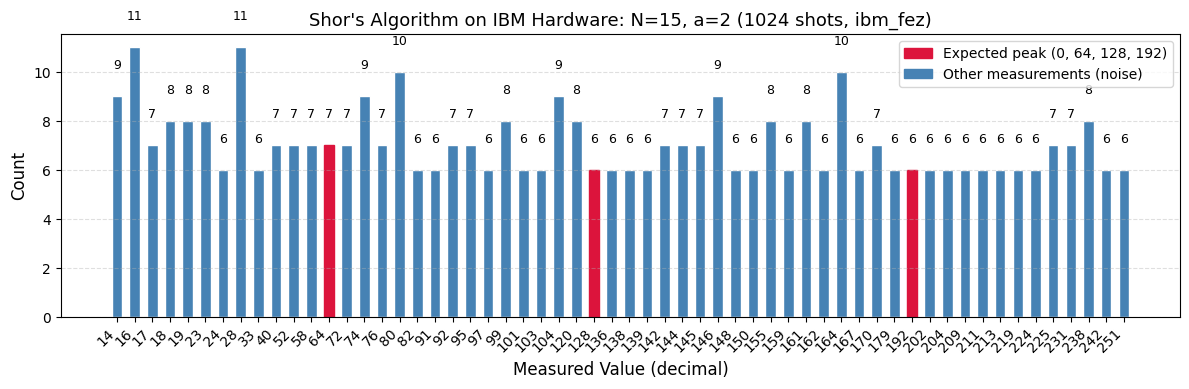

In [19]:
# ── Histogram with decimal x-axis ────────────────────────────────────────

decimal_counts  = {int(k, 2): v for k, v in counts.items()}
filtered_counts = {k: v for k, v in sorted(decimal_counts.items()) if v > 5}

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(range(len(filtered_counts)),
              list(filtered_counts.values()),
              color='steelblue', edgecolor='white', width=0.6)

for bar, count in zip(bars, filtered_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=9)

# Highlight expected peaks from ideal simulation
expected = {0, 64, 128, 192}
keys     = list(filtered_counts.keys())
for i, k in enumerate(keys):
    if k in expected:
        bars[i].set_color('crimson')

ax.set_xticks(range(len(filtered_counts)))
ax.set_xticklabels([str(k) for k in keys], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Measured Value (decimal)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f"Shor's Algorithm on IBM Hardware: N={N}, a={a} ({shots} shots, {backend.name})",
             fontsize=13)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='crimson',  label='Expected peak (0, 64, 128, 192)'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Other measurements (noise)'),
], fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [20]:
# ── Phase extraction ──────────────────────────────────────────────────────

rows_phase = []
for bitstring in sorted(counts, key=lambda x: counts[x], reverse=True):
    count   = counts[bitstring]
    decimal = int(bitstring, 2)
    phase   = decimal / (2**num_control)
    rows_phase.append([
        bitstring, decimal, count,
        f'{count/shots:.1%}',
        f'{decimal}/{2**num_control} = {phase:.4f}'
    ])

print(f'Phase extraction for N={N}, a={a}:')
df_phase = pd.DataFrame(rows_phase[:15],
    columns=['Bitstring', 'Decimal', 'Count', 'Probability', 'Phase'])
print(df_phase.to_string(index=False))

Phase extraction for N=15, a=2:
Bitstring  Decimal  Count Probability            Phase
 00010000       16     11        1.1%  16/256 = 0.0625
 00011100       28     11        1.1%  28/256 = 0.1094
 01010000       80     10        1.0%  80/256 = 0.3125
 10100100      164     10        1.0% 164/256 = 0.6406
 00001110       14      9        0.9%  14/256 = 0.0547
 10010010      146      9        0.9% 146/256 = 0.5703
 01001010       74      9        0.9%  74/256 = 0.2891
 01101000      104      9        0.9% 104/256 = 0.4062
 10011011      155      8        0.8% 155/256 = 0.6055
 00010111       23      8        0.8%  23/256 = 0.0898
 01111000      120      8        0.8% 120/256 = 0.4688
 01100011       99      8        0.8%  99/256 = 0.3867
 10100001      161      8        0.8% 161/256 = 0.6289
 00010010       18      8        0.8%  18/256 = 0.0703
 00010011       19      8        0.8%  19/256 = 0.0742


In [21]:
# ── Period extraction and factoring ──────────────────────────────────────

rows_period   = []
success_shots = 0

for bitstring in sorted(counts, key=lambda x: counts[x], reverse=True):
    count   = counts[bitstring]
    decimal = int(bitstring, 2)
    phase   = decimal / (2**num_control)

    frac  = Fraction(phase).limit_denominator(N)
    r     = frac.denominator
    valid = r > 1 and pow(a, r, N) == 1

    factors = ''
    if valid and r % 2 == 0:
        x = pow(a, r // 2, N)
        if x != N - 1:
            f1, f2 = gcd(x - 1, N), gcd(x + 1, N)
            if 1 < f1 < N:
                factors = f'{f1} x {N // f1}'
                success_shots += count
            elif 1 < f2 < N:
                factors = f'{f2} x {N // f2}'
                success_shots += count

    rows_period.append([
        f'{phase:.4f}', f'{frac.numerator}/{frac.denominator}',
        r, 'Yes' if valid else 'No', count,
        factors if factors else '-'
    ])

print(f'Period extraction and factoring for N={N}, a={a}:')
df_period = pd.DataFrame(rows_period[:15],
    columns=['Phase', 'Fraction', 'Guess for r', 'Valid', 'Count', 'Factors'])
print(df_period.to_string(index=False))

print(f'\nSuccess rate: {100*success_shots/shots:.1f}%  ({success_shots}/{shots} shots)')
if success_shots > 0:
    print(f'Factors found: 3 x 5 = 15  ✓')
    print(f'Avg shots to first success: {round(shots / success_shots)}')
else:
    print('No successful factorisation — hardware noise likely overwhelmed the signal.')
    print('Try: higher shot count, base a=4 (simpler circuit), or a lower-noise device.')

Period extraction and factoring for N=15, a=2:
 Phase Fraction  Guess for r Valid  Count Factors
0.0625     1/15           15    No     11       -
0.1094      1/9            9    No     11       -
0.3125     4/13           13    No     10       -
0.6406     9/14           14    No     10       -
0.0547     1/15           15    No      9       -
0.5703      4/7            7    No      9       -
0.2891      2/7            7    No      9       -
0.4062      2/5            5    No      9       -
0.6055      3/5            5    No      8       -
0.0898     1/11           11    No      8       -
0.4688     7/15           15    No      8       -
0.3867     5/13           13    No      8       -
0.6289      5/8            8   Yes      8       -
0.0703     1/14           14    No      8       -
0.0742     1/13           13    No      8       -

Success rate: 7.9%  (81/1024 shots)
Factors found: 3 x 5 = 15  ✓
Avg shots to first success: 13


In [22]:
# From your job object
print(job.backend().name)

# Or from the backend you connected to
print(backend.name)

# For more details about the device
print(backend.num_qubits)
print(backend.processor_type)

ibm_fez
ibm_fez
156
{'family': 'Heron', 'revision': '2'}
